In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/shared_helper_modules'))

# General imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import pickle

# NeuroDSP and FOOOF modules
from neurodsp import spectral

from specparam import Bands


# Custom modules
from lfp_spike_window_analysis import *

from spe1_plotting import *
from spikeparam.patch.fit import Spike

from config import NPX_CHANNELS, CELL_IDS, DICT_PATCH_FS, DICT_CHAN_PRED, DICT_SPK_THRESH, FILTER_SETTINGS


In [4]:
cell_num =42 #MODIFY THIS WHEN RUNNING DIFFERENT CELLS 

npx_fs = 30000 # sampling rate
lfp_fs = 2500 # sampling rate

patch_fs = DICT_PATCH_FS[cell_num ]
spk_thresh = DICT_SPK_THRESH[cell_num]

npx_channels = NPX_CHANNELS
npx_patch_channel = DICT_CHAN_PRED[cell_num ]

### Loading spe-1 data:

I moved the data loading steps to a separate Jupyter Notebook (spe-1_load_data)




## Cell 42  
### Analyze Gamma LFP and whole patch clamp AP relationship for cell 42

## Step 0: Get loaded data #CHANGE DIRECTORIES FOR CELL DATA

In [5]:
lfp_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c42_lfp_filt.npy'
patch_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c42patch_filt.npy'


In [6]:
#get cell number 
cell_num = lfp_dir.split('/')[len(lfp_dir.split('/'))-1].split('_')[0]

#get LFP data
lfp_filt = np.load(lfp_dir)
lfp_one_ms = float(lfp_fs / 1000)
lfp_times = np.arange(0, np.shape(lfp_filt)[0]) / lfp_one_ms # in ms instead of sec

#get patch data 
patch_filt = np.load(patch_dir)
patch_one_ms = float(patch_fs  / 1000)
patch_times = np.arange(0, np.shape(patch_filt )[0]) / patch_one_ms # in ms instead of sec

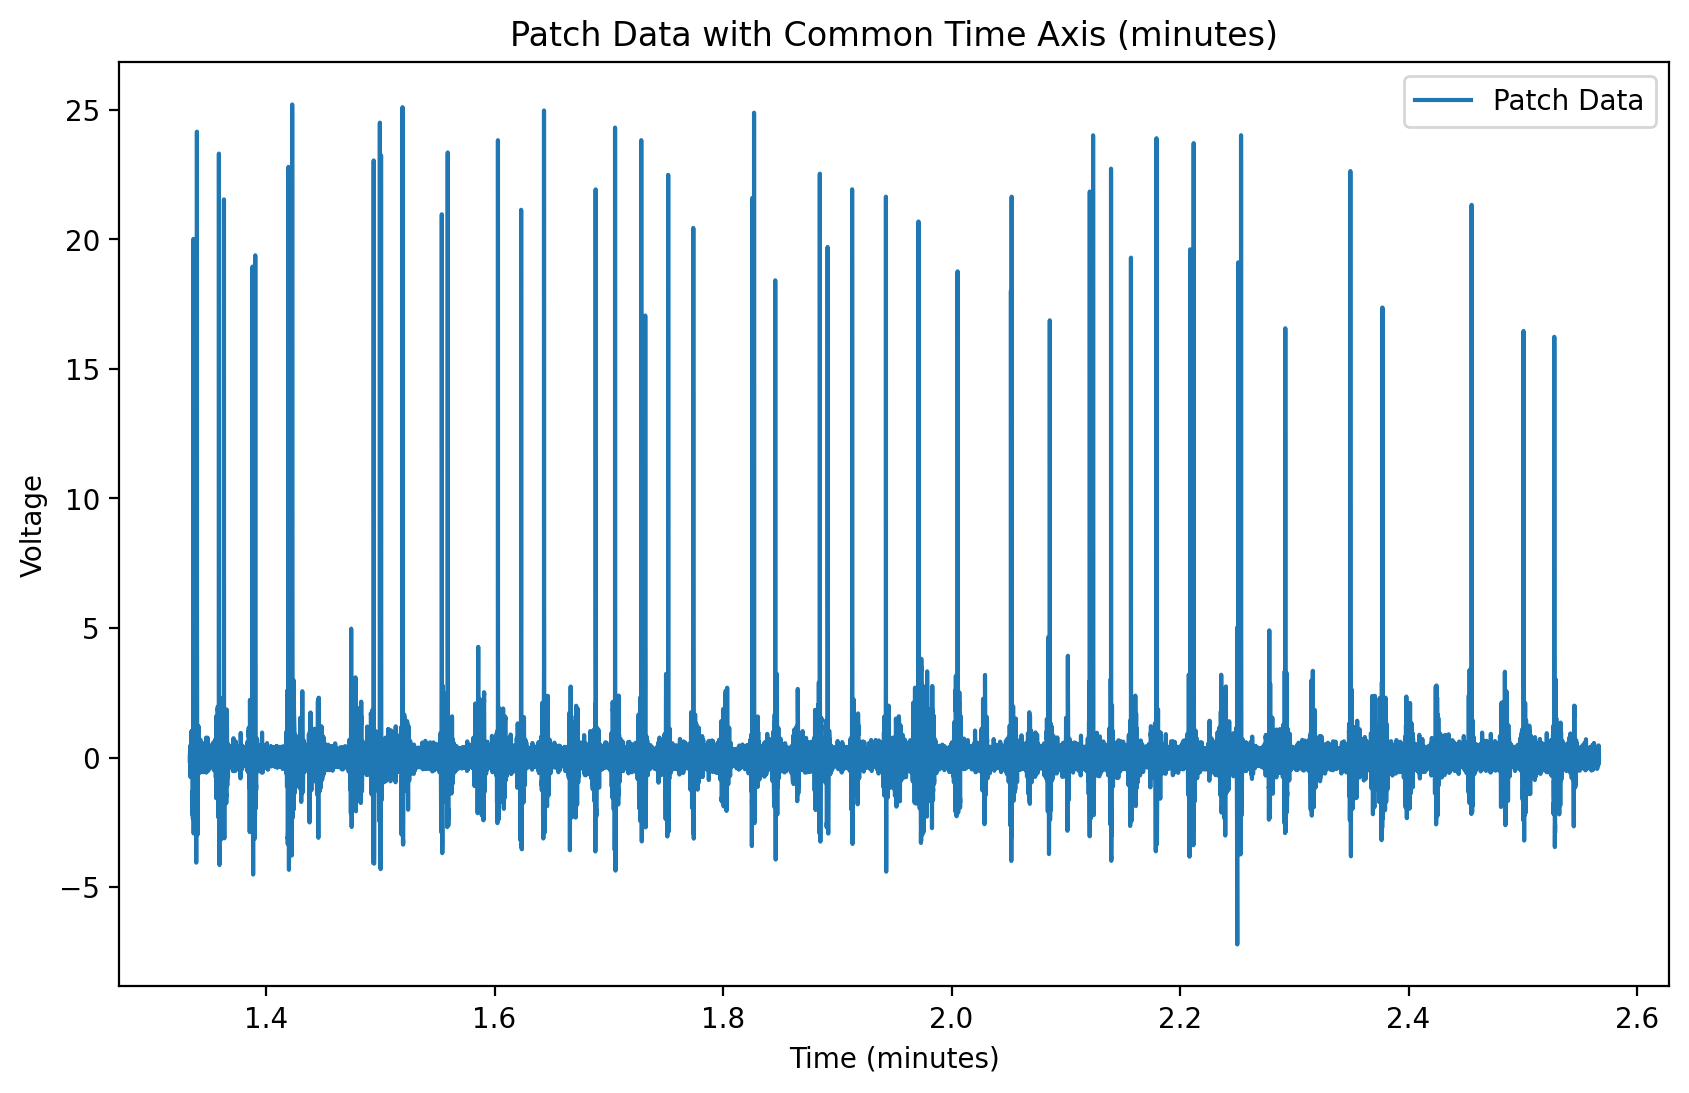

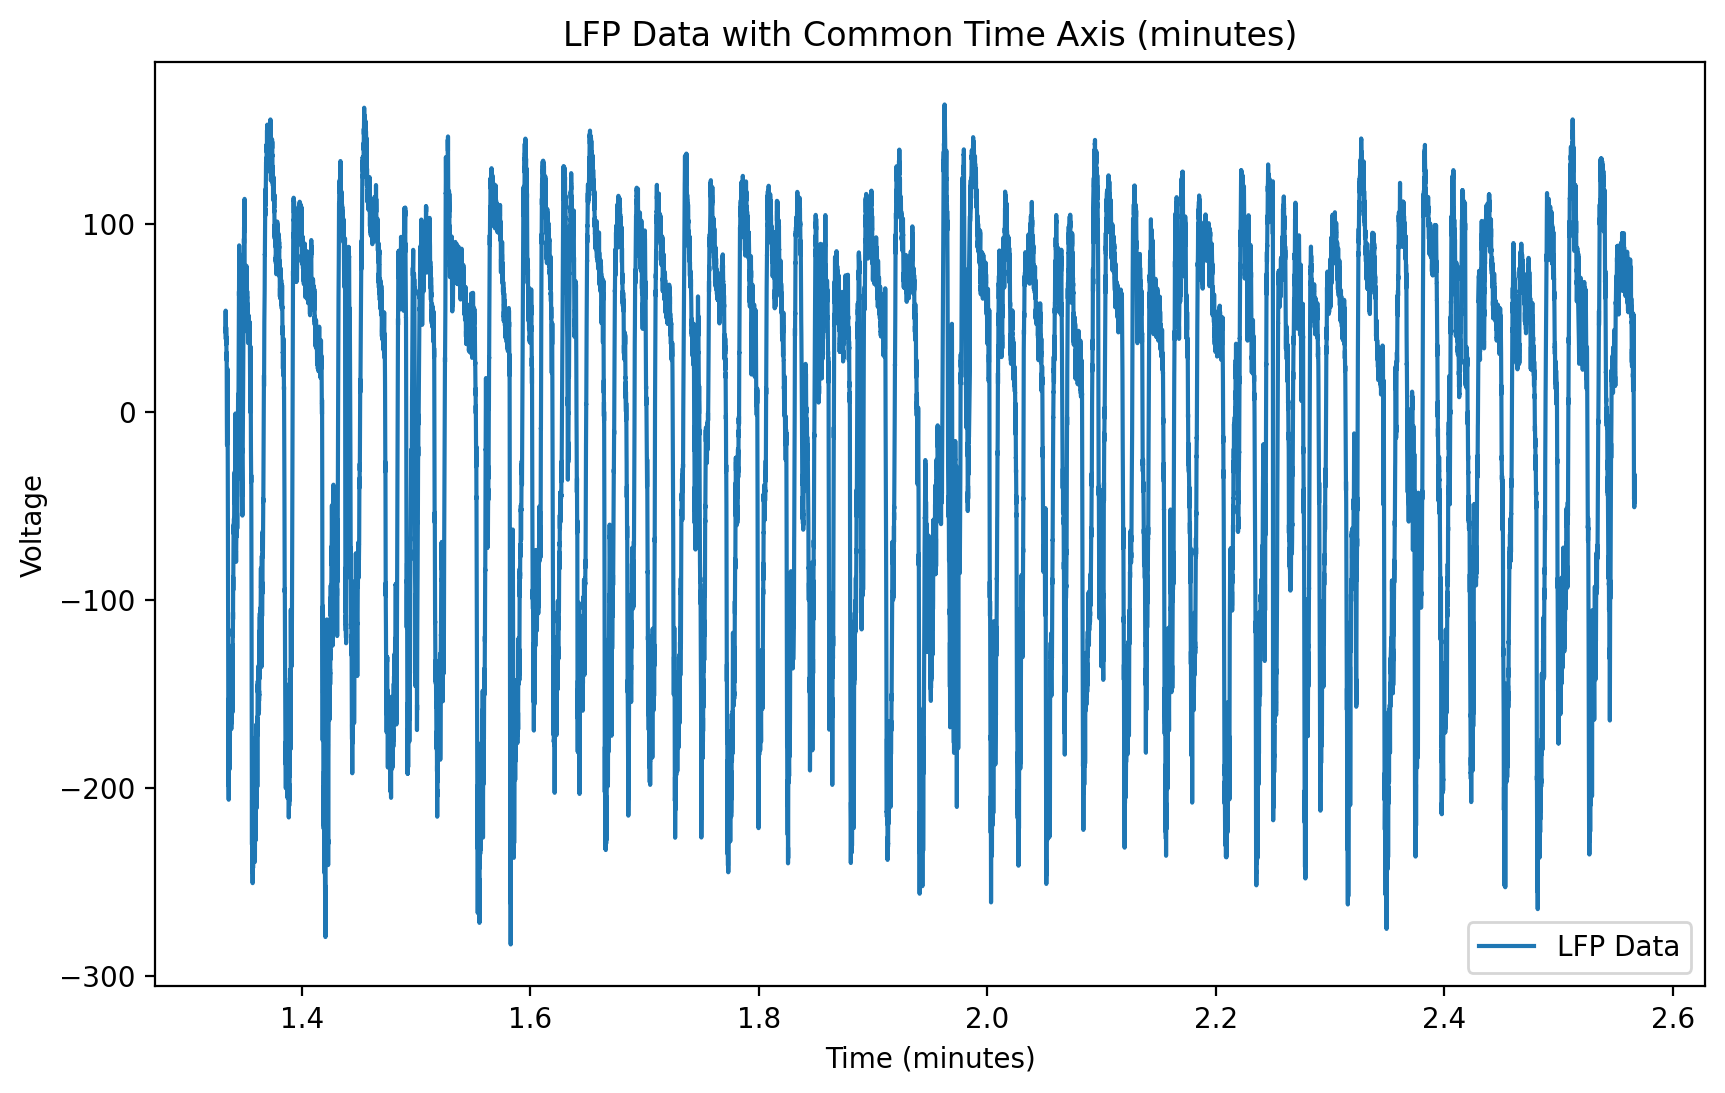

In [7]:
# Plot simultaneous patch and LFP data
# Convert time arrays to minutes
patch_times_min = patch_times / 60000  # Convert milliseconds to minutes
lfp_times_min = lfp_times / 60000  # Convert milliseconds to minutes

# Set the common time axis in minutes (e.g., from 13.3333 to 25.6667 minutes)
common_time_range_min = np.arange(80000 / 60000, 154000 / 60000, 1 / 60000)  # Adjust as needed

# Interpolate patch data onto the common time axis
patch_interp = np.interp(common_time_range_min, patch_times_min, patch_filt)

# Interpolate LFP data onto the common time axis
lfp_interp = np.interp(common_time_range_min, lfp_times_min, lfp_filt)

# Plot patch data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, patch_interp, label='Patch Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('Patch Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

# Plot LFP data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, lfp_interp, label='LFP Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('LFP Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

## STEP 1: ANALYZE LFP DATA BY WINDOWS

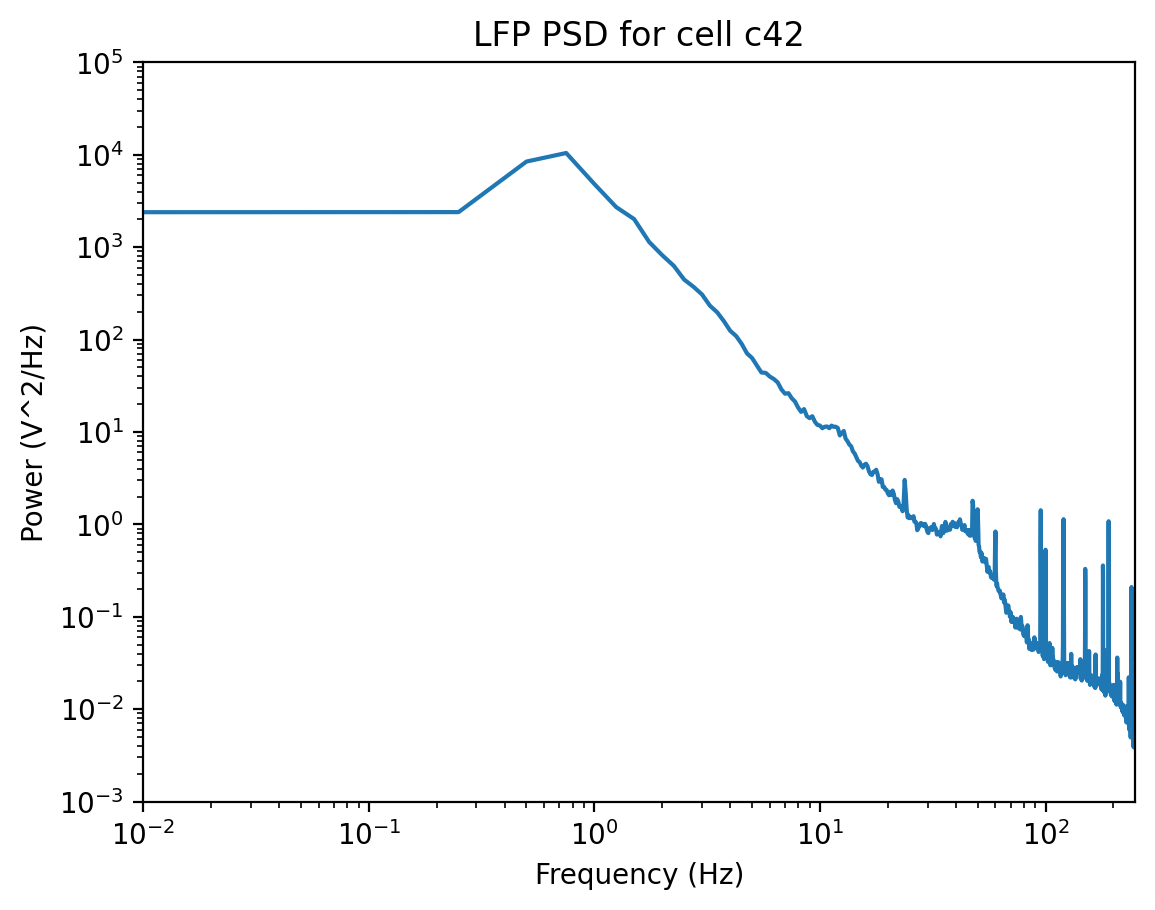

In [8]:
# plot power spectrum
fxx, pxx = spectral.compute_spectrum(lfp_filt, lfp_fs, method='welch', window='hann', nperseg=lfp_fs*4)

xlim = (10e-3, 250)
ylim = (10e-4, 10e4)
plt.loglog(fxx, pxx)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (V^2/Hz)')
plt.xlim(xlim)
plt.ylim(ylim)
plt.title("LFP PSD for cell "+ cell_num)
plt.show()


In [9]:
bands = Bands({'gamma' : [30, 55]})

In [12]:
decim_factor = 500

###### SLIDING WINDOWS APPROACH - Multitaper

In [13]:
model_mt, freqs_mt, window_times_mt = compute_lfp_windows(
    lfp_signal=lfp_filt,
    window_length_sec = 0.1,
    fs=lfp_fs,
    method="multitaper",
    decim_factor = decim_factor
)

summary_df_multitaper = model_mt.to_df()

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Running group fits.: 100%|█████████████████| 4051/4051 [00:34<00:00, 119.04it/s]


Fitting model across 4051 power spectra.
                                                                                                  
                                           TIME RESULTS                                           
                                                                                                  
                                 Number of time windows fit: 4051                                 
                                                                                                  
                        The model was run on the frequency range 1 - 90 Hz                        
                                 Frequency Resolution is 0.35 Hz                                  
                                                                                                  
                              Power spectra were fit without a knee.                              
                                                                    

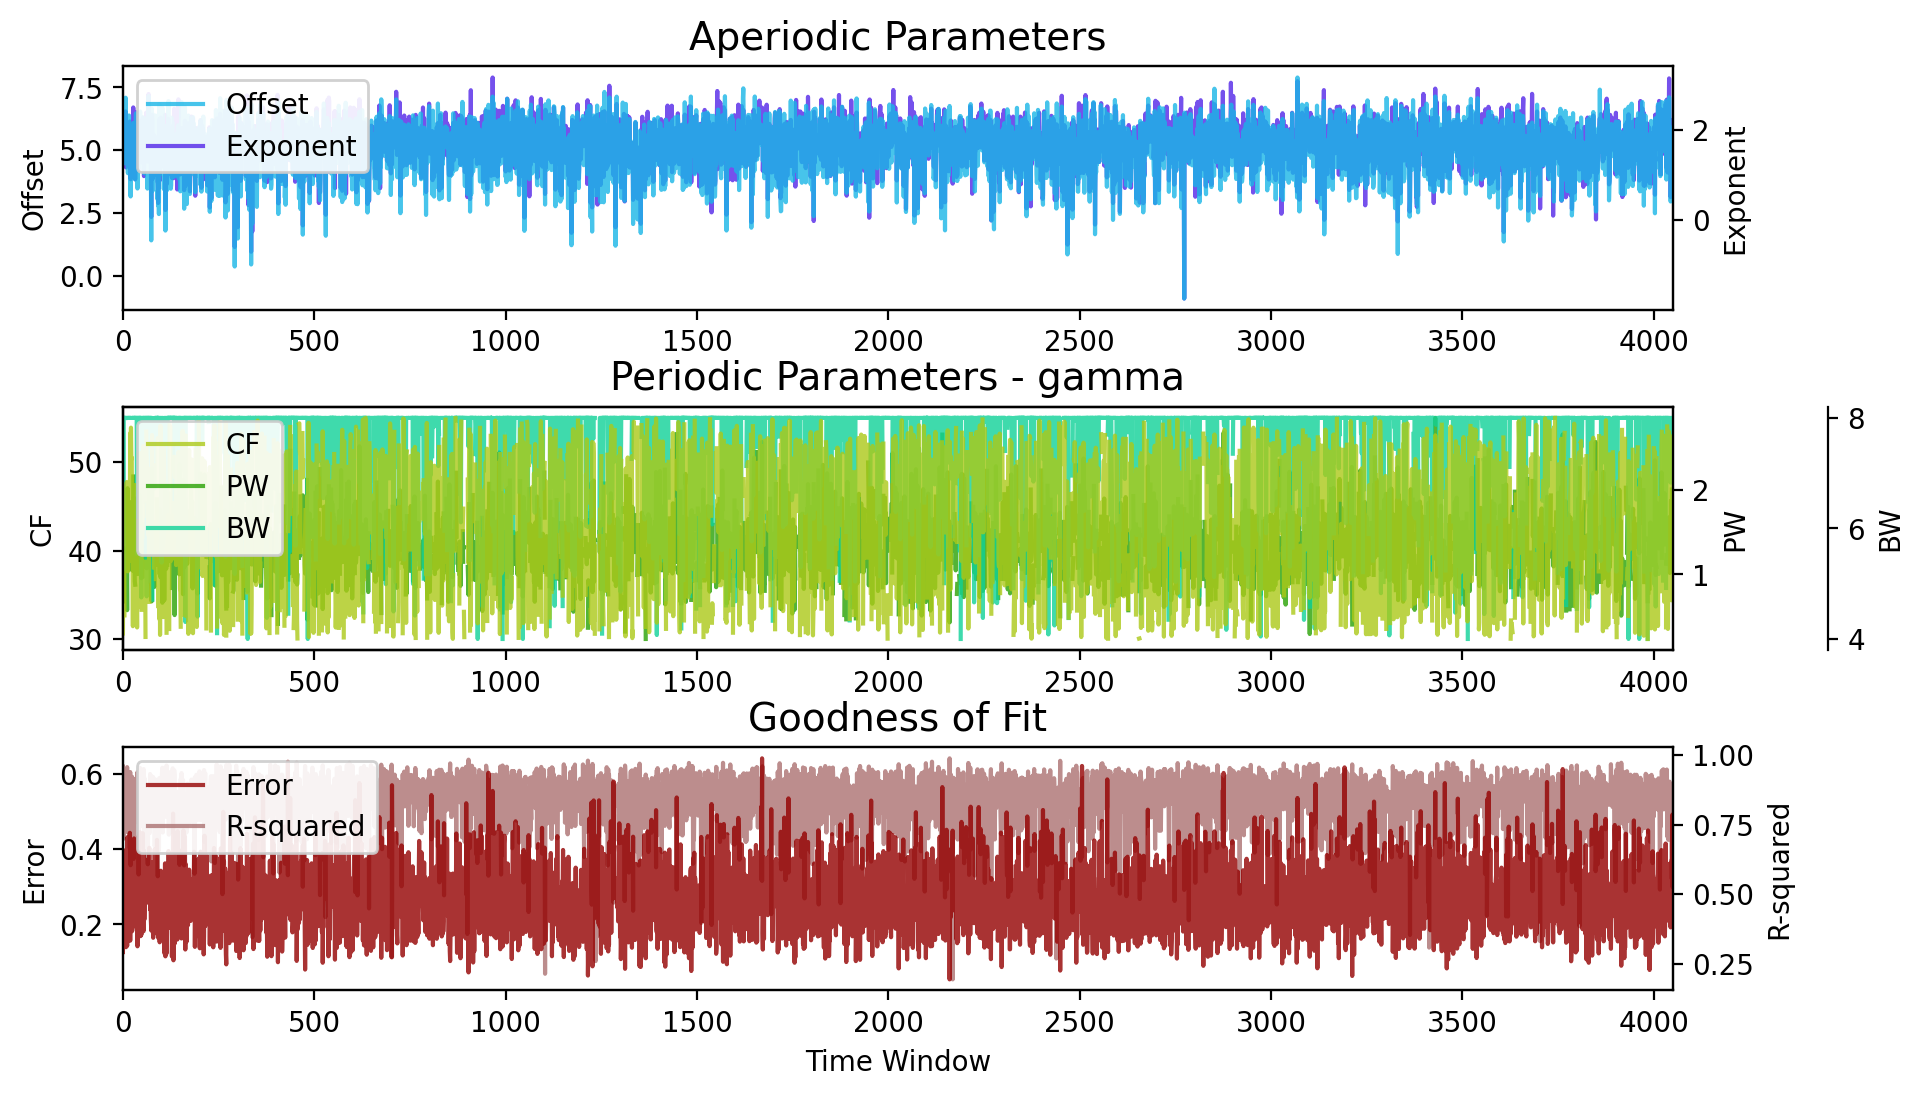

In [14]:
model_mt.report(peak_org=bands)

In [15]:
# Existing summary from specparam (offset, exponent, r_squared, error, n_peaks, etc.)
summary_df_multitaper = model_mt.to_df().reset_index(drop=True)



In [16]:
summary_df_multitaper

,offset,exponent,gamma_cf,gamma_pw,gamma_bw,error,r_squared
0,5.596020,1.534292,30.628172,0.679565,8.000000,0.126576,0.958422
1,6.533382,2.061150,45.243784,1.318945,5.255806,0.338805,0.733584
2,6.844899,2.395043,40.960213,1.149606,8.000000,0.397292,0.699489
3,4.497868,1.284972,44.283549,0.859560,8.000000,0.220414,0.884101
4,4.758808,1.602459,32.675072,1.120106,8.000000,0.187158,0.910717
...,...,...,...,...,...,...,...
4046,5.269708,1.563601,34.375646,1.137640,8.000000,0.306781,0.834166
4047,5.114062,1.194198,47.034038,2.008505,8.000000,0.372715,0.555349
4048,5.301789,1.492906,NaN,NaN,NaN,0.334464,0.811487
4049,5.405960,1.999911,47.547634,1.589427,8.000000,0.492545,0.525381


## STEP 2: Get windows with steepest and flattest exponents 

In [17]:
# Compute 10th and 90th percentiles of exponent
low_thresh = summary_df_multitaper["exponent"].quantile(0.02)
high_thresh = summary_df_multitaper["exponent"].quantile(0.98)

# Subset windows
flattest_windows = summary_df_multitaper[summary_df_multitaper["exponent"] >= high_thresh]
steepest_windows = summary_df_multitaper[summary_df_multitaper["exponent"] <= low_thresh]

print("Flattest (lowest 2%) windows:", flattest_windows.shape[0])
print("Steepest (highest 98%) windows:", steepest_windows.shape[0])

Flattest (lowest 2%) windows: 82
Steepest (highest 98%) windows: 82


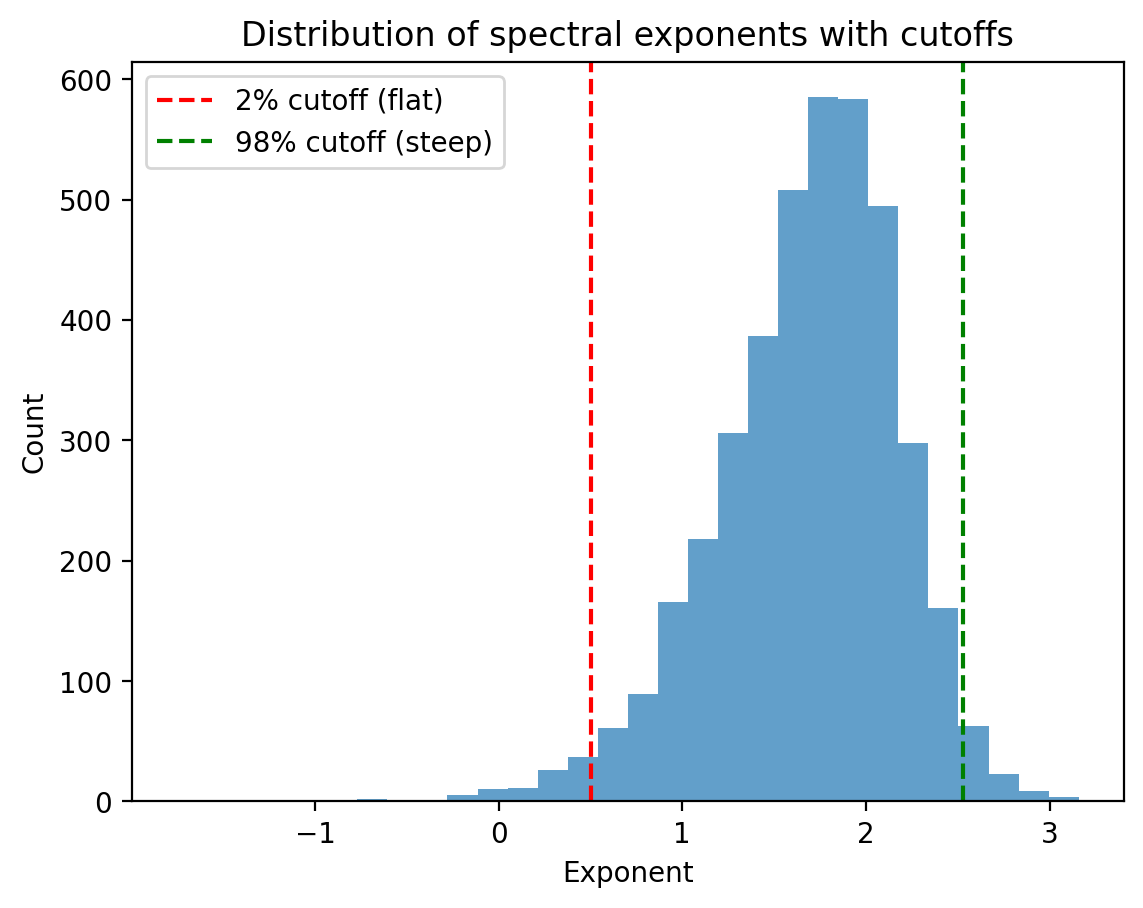

In [18]:
plt.hist(summary_df_multitaper["exponent"], bins=30, alpha=0.7)
plt.axvline(low_thresh, color="red", linestyle="--", label="2% cutoff (flat)")
plt.axvline(high_thresh, color="green", linestyle="--", label="98% cutoff (steep)")
plt.legend()
plt.xlabel("Exponent")
plt.ylabel("Count")
plt.title("Distribution of spectral exponents with cutoffs")
plt.show()


## STEP 3: Detect spikes from patch data

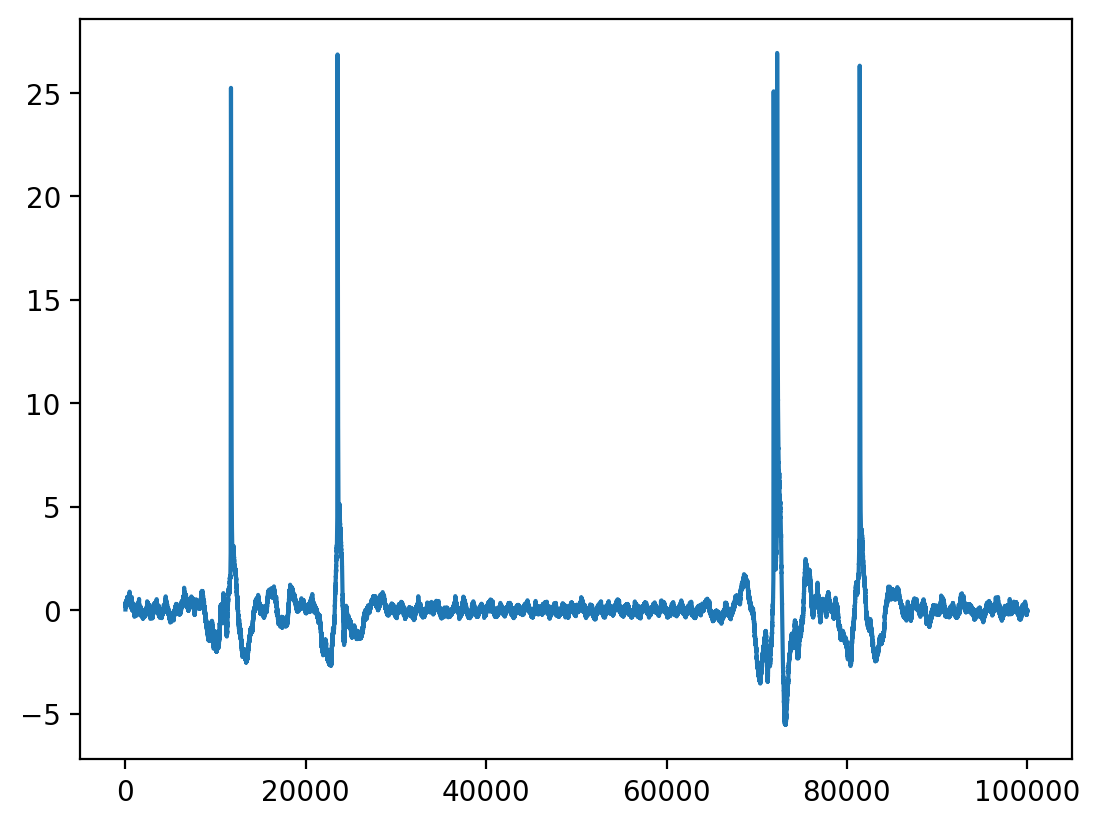

In [19]:
plt.plot(patch_filt[:100000] )

In [20]:



#threshold in mVs
sp = Spike(thresh_amp=spk_thresh, window_length=(5., 5.), smooth_frac=.01)

In [ ]:

sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/1418 [00:00<?, ?it/s]

In [ ]:
sp.plot()

### Filter spikes 

In [ ]:
sp.filter_features()  # Applies default filters in-place

### Get spike dataframe (with spike times column)

In [ ]:

df_features = sp.df_features

#add columns for spike times, both in idx and ms
df_features['spk_times_idx'] = sp.spike_inds
df_features['spk_times_ms'] = patch_times[sp.spike_inds]
df_features['spk_id'] = range(len(df_features))

In [ ]:
df_features

### Get spike times


In [ ]:
spk_times_idx = df_features['spk_times_idx']
spk_times_ms = df_features['spk_times_ms']
spk_ids = df_features['spk_id']

## STEP 4: Map spikes to steepest and flattest LFP windows 

In [ ]:
# make blocks (in seconds) from your window indices
blocks_flat_sec  = [(window_times_mt[i][0] / lfp_fs, window_times_mt[i][1] / lfp_fs)
                    for i in flattest_windows.index]
blocks_steep_sec = [(window_times_mt[i][0] / lfp_fs, window_times_mt[i][1] / lfp_fs)
                    for i in steepest_windows.index]


In [ ]:
spike_df_labeled = label_spikes(
    spike_df=df_features,
    blocks_a=blocks_flat_sec,  label_a="flat",
    blocks_b=blocks_steep_sec, label_b="steep",
    default_label="none",
    time_col="spk_times_ms",
    priority="b",          
    conflicts="none"       
)



In [ ]:
_ = visualize_flat_vs_steep_sanity(
    spike_df=spike_df_labeled,
    summary_df_multitaper=summary_df_multitaper,
    flattest_windows=flattest_windows,
    steepest_windows=steepest_windows,
    window_times_mt=window_times_mt,
    lfp_signal=lfp_filt,
    lfp_fs=lfp_fs,
    time_range=None,               # or (t0, t1)
    color_flat="#009E73",
    color_steep="#CC79A7",
    label_column="method_block_label"
)


In [ ]:
#plot average spectra for steep vs flat windows 
plot_param_spectra_two_groups(
    model_mt,
    group_a=blocks_steep_sec,  # steep
    group_b=blocks_flat_sec,   # flat
    window_times=window_times_mt,
    label_a="Steep", label_b="Flat",
    component="full", space="log",
    freq_range=(1, 150),
    ci="sd",
    lfp_fs=lfp_fs,             # needed for blocks in seconds
    title="Average Parameterized Spectra — Steep vs Flat",
)


In [ ]:


plot_spike_groups_from_labels(
    sp,
    spike_df_labeled,
    label_column="method_block_label",
    label_groups=["flat", "steep"],   # <- only plot these two
    group_names=["Spikes in flatter windows", "Spikes in steeper windows"],
    # optional if your function supports it:
    # colors=["#009E73", "#CC79A7"],
)


In [ ]:
compare_spike_params_groups(
    spike_df_labeled,
    group_col="method_block_label",
    groups=("flat", "steep"),
    params=spike_df_labeled.columns[:-4]
)

